# Mini BERT Pretraining Notebook

한국어 위키 코퍼스를 기반으로 **vocab 8,000 / 약 1M급 파라미터**의 Mini BERT를 직접 사전학습하는 노트북입니다.

## 전체 방향

이 노트북은 단순 실행용 코드가 아니라, **데이터 생성 → 모델 구현 → 사전학습 → 결과 검증**까지의 흐름을 한 번에 설명하도록 재구성했습니다.

| 단계 | 목적 | 핵심 산출물 |
|---|---|---|
| Step 0 | 실행 환경과 재현성 고정 | 라이브러리 버전, device, seed |
| Step 1 | SentencePiece 토크나이저 학습 | `kowiki_bert_8000.model`, `kowiki_bert_8000.vocab` |
| Step 2 | BERT pretrain 샘플 생성 | MLM/NSP 라벨, segment id, memmap 데이터셋 |
| Step 3 | Mini BERT 모델 구현 | Embedding, Attention, Encoder, Pretrain Head |
| Step 4 | 사전학습 실행 | loss/accuracy history, optimizer state |
| Step 5 | 결과 분석과 저장 | 학습 곡선, 모델 가중치, 정량/정성 평가 |

## Special Token 규칙

| Token | ID | 용도 |
|---|---:|---|
| `[PAD]` | 0 | 패딩 위치 |
| `[UNK]` | 1 | 미등록 토큰 |
| `[CLS]` | 2 | 문장쌍 시작 및 NSP 분류 기준 |
| `[SEP]` | 3 | 문장 경계 |
| `[MASK]` | 4 | MLM 예측 대상 위치 |

## 코드 개선 원칙

- 출력 메시지와 주석에서 이모지를 제거해 제출용 형식으로 정리했습니다.
- 중복된 문서 분리 코드를 함수형 구조로 통합했습니다.
- 누락되어 있던 `truncate_pair` 함수를 추가해 NSP 샘플 생성 코드가 독립적으로 실행되도록 수정했습니다.
- 각 단계의 목적, 입력, 처리 방향, 출력이 마크다운으로 드러나도록 재구성했습니다.


In [4]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.7 MB/s eta 0:00:00a 0:00:01


In [5]:
# ===========================================
# Step 0. 실행 환경 설정
# ===========================================
# 목적
# - 필요한 라이브러리를 한 번에 로드한다.
# - GPU 사용 가능 여부를 확인한다.
# - seed를 고정해 전처리와 학습 결과의 재현성을 높인다.

import os
import json
import math
import random
import re
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch


def set_global_seed(seed: int) -> None:
    """Python, NumPy, PyTorch 난수 시드를 한 번에 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
set_global_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Library versions")
print(f"  torch      : {torch.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  matplotlib : {matplotlib.__version__}")
print("\nRuntime")
print(f"  CUDA available : {torch.cuda.is_available()}")
print(f"  Device         : {device}")
if torch.cuda.is_available():
    print(f"  GPU            : {torch.cuda.get_device_name(0)}")
print(f"  Seed           : {SEED}")


Library versions
  torch      : 2.7.1+cu118
  numpy      : 2.2.6
  pandas     : 2.3.0
  matplotlib : 3.10.3

Runtime
  CUDA available : True
  Device         : cuda
  GPU            : Tesla T4
  Seed           : 42


---
# Step 1. Tokenizer 준비

## 방향

한국어 위키 텍스트를 SentencePiece BPE 토크나이저로 변환합니다. BERT는 `[CLS]`, `[SEP]`, `[MASK]` 같은 특수 토큰 위치가 고정되어야 하므로, 토크나이저 학습 단계에서 ID 규칙을 명확히 고정합니다.

| 항목 | 내용 |
|---|---|
| 입력 | `../data/kowiki.txt` |
| 처리 | SentencePiece BPE 학습, special token ID 고정 |
| 출력 | `kowiki_bert_8000.model`, `kowiki_bert_8000.vocab` |
| 검증 | vocab size, special token ID, encode/decode 결과 확인 |

## 핵심 결정

- `pad_id=0`, `unk_id=1`로 고정합니다.
- `[CLS]`, `[SEP]`, `[MASK]`는 `user_defined_symbols`로 등록합니다.
- BOS/EOS는 사용하지 않습니다. BERT는 `[CLS]`와 `[SEP]`로 문장 구조를 표현합니다.


In [6]:
# ===========================================
# Step 1-1. 코퍼스 파일 점검
# ===========================================
# 목적
# - 학습에 사용할 원천 텍스트가 존재하는지 확인한다.
# - 전체 크기, 라인 수, 초반 샘플을 확인해 데이터 이상 여부를 빠르게 점검한다.

CORPUS_PATH = Path("../data/kowiki.txt")

if not CORPUS_PATH.exists():
    raise FileNotFoundError(f"코퍼스 파일을 찾을 수 없습니다: {CORPUS_PATH}")

corpus_size_mb = CORPUS_PATH.stat().st_size / (1024 ** 2)

sample_lines = []
line_count = 0
with CORPUS_PATH.open("r", encoding="utf-8") as f:
    for line_count, line in enumerate(f, start=1):
        if len(sample_lines) < 5:
            sample_lines.append(line.strip())

print("Corpus summary")
print(f"  path      : {CORPUS_PATH}")
print(f"  size      : {corpus_size_mb:.1f} MB")
print(f"  line count: {line_count:,}")
print("\nFirst 5 lines")
for idx, line in enumerate(sample_lines):
    preview = line[:100] + "..." if len(line) > 100 else line
    print(f"  [{idx}] {preview}")


Corpus summary
  path      : ../data/kowiki.txt
  size      : 474.7 MB
  line count: 3,324,967

First 5 lines
  [0] 유, 김삼룡은 출소한 직후인 1933년 초에 경성트로이카를 결성해 본격적인 노동운동을 벌였다.
  [1] 경성트로이카 조직은 서울 지역의 공장 파업을 조종하고 동맹휴학을 일으키며 활동하던 중 1933년 말에 대거 체포되었다. 이현상도 붙잡혀 일년 여에 걸친 재판 끝에 징역 4년형을 언...
  [2] 경성콤그룹이 기관지 《코뮤니스트》를 발행하고 전국적인 노동조직을 갖추어 가던 중, 대대적인 검거사태가 벌어지면서 1940년 이현상이 가장 먼저 체포되었다. 이때는 전시체제가 강화되...
  [3] 이현상은 광복 직후부터 활동을 개시하여 장안파 조선공산당에 대항하는 재건파에 합류했다. 재건파는 곧 장안파를 무력화시키고 조선공산당을 결성했으며, 이현상은 중앙위원과 조직국원으로 ...
  [4] 1947년에 전평의 허성택, 박세형과 함께 체포되었다가 두 달 만에 풀려나기도 했다. 이때 일제 아래 악명 높은 고문전문가이던 노덕술 등으로부터 가혹한 고문을 받았다. 6월 25일...


## Step 1-2. SentencePiece 모델 학습

## 방향

코퍼스를 바로 모델에 넣지 않고 먼저 subword 단위로 분해할 수 있는 토크나이저를 만듭니다. 한국어는 조사와 어미 변화가 많기 때문에 글자 단위보다 BPE 기반 subword가 안정적입니다.

| 옵션 | 값 | 이유 |
|---|---:|---|
| `vocab_size` | 8000 | 과제 규모와 Mini BERT 파라미터 수를 맞추기 위함 |
| `model_type` | `bpe` | 한국어 subword 분리에 적합 |
| `character_coverage` | 0.9995 | 한글과 주요 기호를 넓게 포함 |
| `pad_id / unk_id` | `0 / 1` | BERT 입력 처리 관례 |
| `bos_id / eos_id` | `-1 / -1` | BERT에서는 별도 BOS/EOS를 사용하지 않음 |
| `user_defined_symbols` | `[CLS],[SEP],[MASK]` | BERT pretrain에 필요한 특수 토큰 |


In [7]:
# ===========================================
# Step 1-2. SentencePiece 모델 학습
# ===========================================
# 목적
# - 한국어 위키 텍스트에서 BPE 기반 subword vocab을 학습한다.
# - BERT 입력 규칙에 맞도록 special token ID를 고정한다.

import sentencepiece as spm

MODEL_PREFIX = "kowiki_bert_8000"
VOCAB_SIZE = 8000

spm_options = {
    "input": str(CORPUS_PATH),
    "model_prefix": MODEL_PREFIX,
    "vocab_size": VOCAB_SIZE,
    "model_type": "bpe",
    "character_coverage": 0.9995,
    "pad_id": 0,
    "pad_piece": "[PAD]",
    "unk_id": 1,
    "unk_piece": "[UNK]",
    "bos_id": -1,
    "eos_id": -1,
    "user_defined_symbols": "[CLS],[SEP],[MASK]",
    "input_sentence_size": 1_000_000,
    "shuffle_input_sentence": "true",
    "train_extremely_large_corpus": "true",
}

train_args = " ".join(f"--{key}={value}" for key, value in spm_options.items())

print("SentencePiece training")
print(f"  output model: {MODEL_PREFIX}.model")
print(f"  output vocab: {MODEL_PREFIX}.vocab")

spm.SentencePieceTrainer.Train(train_args)

print("SentencePiece training finished")


SentencePiece training
  output model: kowiki_bert_8000.model
  output vocab: kowiki_bert_8000.vocab
SentencePiece training finished


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=../data/kowiki.txt --model_prefix=kowiki_bert_8000 --vocab_size=8000 --model_type=bpe --character_coverage=0.9995 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=-1 --eos_id=-1 --user_defined_symbols=[CLS],[SEP],[MASK] --input_sentence_size=1000000 --shuffle_input_sentence=true --train_extremely_large_corpus=true
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ../data/kowiki.txt
  input_format: 
  model_prefix: kowiki_bert_8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 1000000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_w

## Step 1-3. Tokenizer 로드 및 검증

## 방향

학습된 SentencePiece 모델이 BERT 입력 규칙에 맞는지 확인합니다. 이 단계가 틀리면 이후 데이터셋, 모델 입력, MLM 라벨이 모두 어긋납니다.

| 검증 항목 | 기준 |
|---|---|
| vocab 크기 | 8,000 |
| special token ID | `[PAD]=0`, `[UNK]=1`, `[CLS]=2`, `[SEP]=3`, `[MASK]=4` |
| 한국어 토큰화 | 의미 있는 subword 분해 여부 |
| 복원성 | encode 후 decode 결과가 자연스러운지 확인 |


In [8]:
# ===========================================
# Step 1-3. Tokenizer 로드 및 검증
# ===========================================
# 목적
# - 방금 학습한 tokenizer를 로드한다.
# - vocab 크기와 special token ID가 설계대로 고정되었는지 검증한다.

MODEL_PATH = f"{MODEL_PREFIX}.model"

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(MODEL_PATH)

vocab_size = tokenizer.GetPieceSize()
print(f"Vocab size: {vocab_size:,}")
assert vocab_size == VOCAB_SIZE, f"vocab_size 불일치: {vocab_size} != {VOCAB_SIZE}"

special_tokens = {
    "[PAD]": 0,
    "[UNK]": 1,
    "[CLS]": 2,
    "[SEP]": 3,
    "[MASK]": 4,
}

print("\nSpecial token check")
for token, expected_id in special_tokens.items():
    actual_id = tokenizer.PieceToId(token)
    status = "OK" if actual_id == expected_id else "FAIL"
    print(f"  {status:4s} {token:7s} id={actual_id} expected={expected_id}")
    assert actual_id == expected_id, f"{token} ID 불일치: {actual_id} != {expected_id}"

PAD_ID = special_tokens["[PAD]"]
UNK_ID = special_tokens["[UNK]"]
CLS_ID = special_tokens["[CLS]"]
SEP_ID = special_tokens["[SEP]"]
MASK_ID = special_tokens["[MASK]"]

print("\nKorean tokenization samples")
samples = [
    "한국어 BERT 모델을 사전학습합니다.",
    "자연어 처리는 인공지능의 핵심 분야이다.",
    "트랜스포머는 어텐션 메커니즘을 사용한다.",
]

for sentence in samples:
    pieces = tokenizer.EncodeAsPieces(sentence)
    ids = tokenizer.EncodeAsIds(sentence)
    decoded = tokenizer.DecodeIds(ids)
    print(f"\n원문: {sentence}")
    print(f"조각: {pieces}")
    print(f"ID  : {ids}")
    print(f"복원: {decoded}")

print("\nTokenizer validation finished")


Vocab size: 8,000

Special token check
  OK   [PAD]   id=0 expected=0
  OK   [UNK]   id=1 expected=1
  OK   [CLS]   id=2 expected=2
  OK   [SEP]   id=3 expected=3
  OK   [MASK]  id=4 expected=4

Korean tokenization samples

원문: 한국어 BERT 모델을 사전학습합니다.
조각: ['▁한국', '어', '▁B', 'E', 'R', 'T', '▁모델', '을', '▁사', '전', '학', '습', '합', '니다', '.']
ID  : [332, 3569, 372, 3825, 3851, 3764, 1222, 3541, 14, 3573, 3622, 3941, 3748, 1152, 3533]
복원: 한국어 BERT 모델을 사전학습합니다.

원문: 자연어 처리는 인공지능의 핵심 분야이다.
조각: ['▁자연', '어', '▁처', '리는', '▁인', '공', '지', '능', '의', '▁핵', '심', '▁분야', '이다', '.']
ID  : [1165, 3569, 287, 368, 40, 3605, 3543, 3849, 3535, 1219, 3783, 1566, 12, 3533]
복원: 자연어 처리는 인공지능의 핵심 분야이다.

원문: 트랜스포머는 어텐션 메커니즘을 사용한다.
조각: ['▁트', '랜', '스', '포', '머', '는', '▁어', '텐', '션', '▁메', '커', '니', '즘', '을', '▁사용한다', '.']
ID  : [412, 3907, 3559, 3681, 3889, 3536, 135, 4194, 3919, 320, 3947, 3666, 4280, 3541, 2597, 3533]
복원: 트랜스포머는 어텐션 메커니즘을 사용한다.

Tokenizer validation finished


---
# Step 2. Pretrain 데이터셋 생성

## 방향

BERT 사전학습에 필요한 두 가지 과제인 **MLM**과 **NSP**를 동시에 만들기 위한 데이터 전처리 단계입니다.

| 배열 | shape | 역할 |
|---|---|---|
| `enc_tokens` | `(N, max_len)` | 모델 입력 토큰. 일부 위치는 `[MASK]` 또는 랜덤 토큰으로 치환 |
| `segments` | `(N, max_len)` | 문장 A는 0, 문장 B는 1 |
| `labels_mlm` | `(N, max_len)` | MLM 정답 토큰. 예측하지 않는 위치는 `-1` |
| `labels_nsp` | `(N,)` | 실제 다음 문장이면 1, 무작위 문장이면 0 |

## 입력 구조

```text
[CLS] A tokens [SEP] B tokens [SEP] [PAD] ...
segment: 0 ... 0      0     1 ... 1      1     0
```

## 처리 순서

1. 문서와 문장을 분리합니다.
2. 모든 문장을 SentencePiece ID로 변환합니다.
3. NSP 문장쌍을 생성합니다.
4. MLM 마스킹을 적용합니다.
5. 메모리 효율을 위해 `np.memmap`으로 저장합니다.


In [9]:
# ===========================================
# Step 2-0. 데이터 전처리 하이퍼파라미터
# ===========================================
# 목적
# - 시퀀스 길이, 생성할 pair 수, MLM/NSP 비율을 한곳에서 관리한다.
# - 이후 실험 규모를 바꿀 때 이 셀만 수정하면 되도록 한다.

MAX_LEN = 128
MAX_PAIRS = 200_000

MASK_RATIO = 0.15
MLM_MASK_PROB = 0.8
MLM_RANDOM_PROB = 0.1
MLM_KEEP_PROB = 0.1
IGNORE_INDEX = -1

NSP_TRUE_RATIO = 0.5

print("Preprocessing config")
print(f"  MAX_LEN       : {MAX_LEN}")
print(f"  MAX_PAIRS     : {MAX_PAIRS:,}")
print(f"  MASK_RATIO    : {MASK_RATIO}")
print(f"  MLM 80/10/10  : {MLM_MASK_PROB} / {MLM_RANDOM_PROB} / {MLM_KEEP_PROB}")
print(f"  NSP true ratio: {NSP_TRUE_RATIO}")


Preprocessing config
  MAX_LEN       : 128
  MAX_PAIRS     : 200,000
  MASK_RATIO    : 0.15
  MLM 80/10/10  : 0.8 / 0.1 / 0.1
  NSP true ratio: 0.5


## Step 2-1. 문서 단위 읽기

## 방향

NSP의 `is_next=True` 샘플은 반드시 같은 문서 안에서 이어지는 문장으로 만들어야 합니다. 따라서 먼저 코퍼스를 문서 단위로 나누고, 너무 짧은 문장과 문서는 제거합니다.

| 항목 | 기준 |
|---|---|
| 문서 구분 | 빈 줄 |
| 문장 최소 길이 | `MIN_SENT_LEN` 이상 |
| 문서 최소 문장 수 | `MIN_DOC_SENT` 이상 |
| 출력 | `documents: List[List[str]]` |


In [10]:
# ===========================================
# Step 2-1. kowiki.txt를 문서 단위로 분리
# ===========================================
# 목적
# - 빈 줄을 문서 경계로 해석한다.
# - 너무 짧은 문장과 문서를 제거해 NSP pair 품질을 높인다.

from tqdm.auto import tqdm

MIN_SENT_LEN = 5
MIN_DOC_SENT = 2


def load_documents_from_corpus(
    corpus_path: Path,
    min_sent_len: int = MIN_SENT_LEN,
    min_doc_sent: int = MIN_DOC_SENT,
):
    """코퍼스 파일을 List[List[str]] 형태의 문서 목록으로 변환한다."""
    documents = []
    current_doc = []

    with corpus_path.open("r", encoding="utf-8") as f:
        for raw_line in tqdm(f, desc="Loading documents"):
            line = raw_line.strip()

            if line == "":
                if len(current_doc) >= min_doc_sent:
                    documents.append(current_doc)
                current_doc = []
                continue

            if len(line) >= min_sent_len:
                current_doc.append(line)

    if len(current_doc) >= min_doc_sent:
        documents.append(current_doc)

    return documents


documents = load_documents_from_corpus(CORPUS_PATH)

total_sents = sum(len(doc) for doc in documents)
avg_sents = total_sents / len(documents) if documents else 0.0

print("Document split summary")
print(f"  documents       : {len(documents):,}")
print(f"  total sentences : {total_sents:,}")
print(f"  avg sentences   : {avg_sents:.1f}")

if not documents:
    raise ValueError("유효한 문서를 찾지 못했습니다. 코퍼스 구조와 필터 조건을 확인하세요.")

print("\nFirst document sample")
for idx, sent in enumerate(documents[0][:3]):
    preview = sent[:80] + "..." if len(sent) > 80 else sent
    print(f"  [{idx}] {preview}")


Loading documents: 0it [00:00, ?it/s]

Document split summary
  documents       : 377,301
  total sentences : 1,770,543
  avg sentences   : 4.7

First document sample
  [0] 유, 김삼룡은 출소한 직후인 1933년 초에 경성트로이카를 결성해 본격적인 노동운동을 벌였다.
  [1] 경성트로이카 조직은 서울 지역의 공장 파업을 조종하고 동맹휴학을 일으키며 활동하던 중 1933년 말에 대거 체포되었다. 이현상도 붙잡혀 일년 여...
  [2] 경성콤그룹이 기관지 《코뮤니스트》를 발행하고 전국적인 노동조직을 갖추어 가던 중, 대대적인 검거사태가 벌어지면서 1940년 이현상이 가장 먼저 ...


## Step 2-2. 문장 토큰화

## 방향

문자열 문장을 모델 입력에 사용할 수 있는 토큰 ID 배열로 바꿉니다. 이후 NSP와 MLM은 모두 토큰 ID 기준으로 처리되므로, 이 단계에서 빈 시퀀스와 짧은 문서를 정리합니다.

| 입력 | 처리 | 출력 |
|---|---|---|
| `documents` | SentencePiece `EncodeAsIds` 적용 | `tokenized_docs` |


In [11]:
# ===========================================
# Step 2-2. 모든 문서를 토큰 ID로 변환
# ===========================================
# 목적
# - 문자열 문장 단위를 SentencePiece token id 단위로 변환한다.
# - 토큰화 후 문장이 2개 이상 남는 문서만 유지한다.


def tokenize_documents(documents, tokenizer, min_doc_sent: int = MIN_DOC_SENT):
    """문서 목록을 token id 문서 목록으로 변환한다."""
    tokenized_docs = []

    for doc in tqdm(documents, desc="Tokenizing documents"):
        tokenized_doc = []
        for sentence in doc:
            token_ids = tokenizer.EncodeAsIds(sentence)
            if token_ids:
                tokenized_doc.append(token_ids)

        if len(tokenized_doc) >= min_doc_sent:
            tokenized_docs.append(tokenized_doc)

    return tokenized_docs


tokenized_docs = tokenize_documents(documents, tokenizer)

total_tok_sents = sum(len(doc) for doc in tokenized_docs)
total_tokens = sum(len(sent) for doc in tokenized_docs for sent in doc)
avg_tok_per_sent = total_tokens / total_tok_sents if total_tok_sents else 0.0

print("Tokenization summary")
print(f"  documents       : {len(tokenized_docs):,}")
print(f"  tokenized sents : {total_tok_sents:,}")
print(f"  total tokens    : {total_tokens:,}")
print(f"  avg token/sent  : {avg_tok_per_sent:.1f}")

if not tokenized_docs:
    raise ValueError("토큰화 후 남은 문서가 없습니다. tokenizer와 필터 조건을 확인하세요.")


Tokenizing documents:   0%|          | 0/377301 [00:00<?, ?it/s]

Tokenization summary
  documents       : 377,301
  tokenized sents : 1,770,543
  total tokens    : 118,295,235
  avg token/sent  : 66.8


## Step 2-3. NSP Pair 생성

## 방향

BERT 원형 구조에 맞춰 문장 A와 문장 B를 구성합니다. 절반은 실제 다음 문장, 절반은 다른 문서에서 가져온 무작위 문장으로 만듭니다.

## 생성 로직

1. 한 문서의 문장을 chunk에 누적합니다.
2. 목표 길이에 도달하면 chunk를 A/B로 나눕니다.
3. `NSP_TRUE_RATIO`에 따라 B를 같은 chunk에서 가져오거나 다른 문서에서 가져옵니다.
4. `[CLS] A [SEP] B [SEP]` 구조로 조립합니다.
5. 길이가 길면 `truncate_pair`로 A/B를 균형 있게 줄입니다.

| 출력 필드 | 의미 |
|---|---|
| `tokens` | `[CLS] A [SEP] B [SEP]` 토큰 ID |
| `segments` | A 영역 0, B 영역 1 |
| `is_next` | 실제 다음 문장이면 1, 무작위 문장이면 0 |


In [12]:
# ===========================================
# Step 2-3. NSP pair 생성
# ===========================================
# 목적
# - 한 문서 안의 연속 문장으로 is_next=True 샘플을 만든다.
# - 다른 문서의 문장으로 is_next=False 샘플을 만든다.
# - BERT 입력 형식인 [CLS] A [SEP] B [SEP]로 조립한다.

SHORT_SEQ_PROB = 0.1


def truncate_pair(tokens_a, tokens_b, max_num_tokens, rng):
    """A/B 합산 길이가 max_num_tokens 이하가 될 때까지 긴 쪽을 줄인다."""
    while len(tokens_a) + len(tokens_b) > max_num_tokens:
        target = tokens_a if len(tokens_a) > len(tokens_b) else tokens_b
        if rng.random() < 0.5:
            del target[0]
        else:
            target.pop()


def create_instances_from_document(doc_idx, max_len, short_seq_prob, rng):
    """하나의 문서에서 BERT pretrain instance를 생성한다."""
    document = tokenized_docs[doc_idx]
    max_num_tokens = max_len - 3

    target_seq_length = max_num_tokens
    if rng.random() < short_seq_prob:
        target_seq_length = rng.randint(2, max_num_tokens)

    instances = []
    current_chunk = []
    current_length = 0
    i = 0

    while i < len(document):
        segment = document[i]
        current_chunk.append(segment)
        current_length += len(segment)

        is_last = i == len(document) - 1
        is_full = current_length >= target_seq_length

        # A/B를 나누려면 chunk 안에 최소 2개 문장이 있어야 한다.
        if is_last or (is_full and len(current_chunk) >= 2):
            if len(current_chunk) >= 2:
                a_end = rng.randint(1, len(current_chunk) - 1)

                tokens_a = []
                for j in range(a_end):
                    tokens_a.extend(current_chunk[j])

                tokens_b = []
                is_random_next = rng.random() >= NSP_TRUE_RATIO

                if is_random_next:
                    target_b_length = target_seq_length - len(tokens_a)

                    for _ in range(10):
                        random_doc_idx = rng.randint(0, len(tokenized_docs) - 1)
                        if random_doc_idx != doc_idx:
                            break

                    random_doc = tokenized_docs[random_doc_idx]
                    random_start = rng.randint(0, len(random_doc) - 1)

                    for j in range(random_start, len(random_doc)):
                        tokens_b.extend(random_doc[j])
                        if len(tokens_b) >= target_b_length:
                            break

                    # 현재 chunk에서 B로 쓰지 않은 뒷부분은 다음 instance 후보로 되돌린다.
                    unused_count = len(current_chunk) - a_end
                    i -= unused_count
                else:
                    for j in range(a_end, len(current_chunk)):
                        tokens_b.extend(current_chunk[j])

                if tokens_a and tokens_b:
                    truncate_pair(tokens_a, tokens_b, max_num_tokens, rng)

                    tokens = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
                    segments = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

                    assert len(tokens) == len(segments)
                    assert len(tokens) <= max_len

                    instances.append({
                        "tokens": tokens,
                        "segments": segments,
                        "is_next": 0 if is_random_next else 1,
                    })

            current_chunk = []
            current_length = 0

        i += 1

    return instances


rng = random.Random(SEED)
all_instances = []

print(f"Creating NSP pairs: target={MAX_PAIRS:,}")
for doc_idx in tqdm(range(len(tokenized_docs)), desc="Creating pairs"):
    instances = create_instances_from_document(doc_idx, MAX_LEN, SHORT_SEQ_PROB, rng)
    all_instances.extend(instances)

    if len(all_instances) >= MAX_PAIRS:
        all_instances = all_instances[:MAX_PAIRS]
        break

rng.shuffle(all_instances)

if not all_instances:
    raise ValueError("NSP instance가 생성되지 않았습니다. 문서 길이와 MAX_LEN을 확인하세요.")

n_true = sum(1 for instance in all_instances if instance["is_next"] == 1)
n_false = len(all_instances) - n_true
avg_len = np.mean([len(instance["tokens"]) for instance in all_instances])

print("NSP pair summary")
print(f"  instances     : {len(all_instances):,}")
print(f"  is_next=True  : {n_true:,} ({n_true / len(all_instances) * 100:.1f}%)")
print(f"  is_next=False : {n_false:,} ({n_false / len(all_instances) * 100:.1f}%)")
print(f"  avg length    : {avg_len:.1f} / {MAX_LEN}")


Creating NSP pairs: target=200,000


Creating pairs:   0%|          | 0/377301 [00:00<?, ?it/s]

NSP pair summary
  instances     : 200,000
  is_next=True  : 100,030 (50.0%)
  is_next=False : 99,970 (50.0%)
  avg length    : 116.1 / 128


### 검증 방향: NSP 샘플 육안 점검

생성된 instance가 `[CLS] A [SEP] B [SEP]` 구조를 갖는지 확인합니다. 이 단계는 label 비율보다 실제 문장 연결이 자연스러운지를 보는 데 중요합니다.


In [13]:
# ===========================================
# Step 2-3 검증. 생성된 pair 샘플 확인
# ===========================================
# 목적
# - 생성된 NSP 샘플이 문장 A/B 구조를 갖는지 육안으로 확인한다.

print("Pair samples")
for sample_idx, instance in enumerate(all_instances[:3]):
    tokens = instance["tokens"]
    sep_positions = [idx for idx, token_id in enumerate(tokens) if token_id == SEP_ID]

    seg_a_text = tokenizer.DecodeIds(tokens[1:sep_positions[0]])
    seg_b_text = tokenizer.DecodeIds(tokens[sep_positions[0] + 1:sep_positions[1]])

    print(f"\nSample {sample_idx} | is_next={instance['is_next']}")
    print(f"  Segment A: {seg_a_text[:80]}{'...' if len(seg_a_text) > 80 else ''}")
    print(f"  Segment B: {seg_b_text[:80]}{'...' if len(seg_b_text) > 80 else ''}")
    print(f"  Length   : {len(tokens)} tokens")


Pair samples

Sample 0 | is_next=1
  Segment A: 이승원 (방송인)
  Segment B: 월 25일 ~ )은 대한민국의 방송인, 게임 해설자이다. 승원좌, 무당 해설이라는 닉네임으로도 각각 유명하다. 한 인터넷 통신 회사에서 근무하다...
  Length   : 128 tokens

Sample 1 | is_next=0
  Segment A: 경제사는 다양한 관점에 따른 이론 간의 이견이 존재하는 학문이다. 오늘날에도 여전히 경제사에 대한 학자간 논쟁이 벌어지고 있다.
  Segment B: 원래는 2면 3선식 승강장이었다가 중간 선로를 철거하여 생긴 2면 2선의 승강장이 있는 지상역이다. 양 승강장은 구내 건널목으로 연결되어 있으며...
  Length   : 82 tokens

Sample 2 | is_next=0
  Segment A: , 2004년에 'Tha Carter', 2005년에는 'Tha Carter II'를 발매하며, 그는 단지 젊은 랩퍼의 재능 이상을 보여주기 시...
  Segment B: 산객이 찾고 있으며, 동쪽으로는 한밭종합운동장과 서쪽으로는 농협중앙회 충남지역본부가 인접해 있고, 충남대학교병원이 있다. 특히 보문산 공원에는 ...
  Length   : 128 tokens


## Step 2-4. MLM 마스킹 적용

## 방향

BERT의 Masked Language Modeling 규칙을 적용합니다. 전체 후보 토큰 중 15%를 예측 대상으로 고르고, 선택된 위치에 80/10/10 규칙을 적용합니다.

| 선택된 위치 처리 | 비율 | 설명 |
|---|---:|---|
| `[MASK]`로 치환 | 80% | 모델이 가려진 토큰을 예측하게 함 |
| 랜덤 토큰으로 치환 | 10% | 입력 노이즈에 대한 견고성 확보 |
| 원래 토큰 유지 | 10% | 실제 fine-tuning 입력과의 분포 차이를 줄임 |

`labels_mlm`에는 어떤 경우든 원래 토큰 ID를 저장합니다. 마스킹하지 않은 위치는 `IGNORE_INDEX=-1`로 표시해 loss 계산에서 제외합니다.


In [14]:
# ===========================================
# Step 2-4. MLM 마스킹과 패딩 적용
# ===========================================
# 목적
# - NSP instance에 MLM noise를 추가한다.
# - 고정 길이 배열 4종을 생성한다.

N = len(all_instances)

enc_tokens = np.full((N, MAX_LEN), PAD_ID, dtype=np.int32)
segments = np.zeros((N, MAX_LEN), dtype=np.int32)
labels_mlm = np.full((N, MAX_LEN), IGNORE_INDEX, dtype=np.int32)
labels_nsp = np.zeros(N, dtype=np.int32)

SPECIAL_IDS = {CLS_ID, SEP_ID}
RAND_LOW = 5
RAND_HIGH = VOCAB_SIZE

rng_np = np.random.RandomState(SEED)
masked_token_count = 0

print("Applying MLM masking")
for row_idx, instance in enumerate(tqdm(all_instances, desc="Masking")):
    tokens = list(instance["tokens"])
    segs = instance["segments"]
    seq_len = len(tokens)

    candidate_positions = [idx for idx, token_id in enumerate(tokens) if token_id not in SPECIAL_IDS]
    n_to_mask = max(1, int(round(len(candidate_positions) * MASK_RATIO)))
    n_to_mask = min(n_to_mask, len(candidate_positions))

    rng_np.shuffle(candidate_positions)
    masked_positions = candidate_positions[:n_to_mask]

    for pos in masked_positions:
        original_token = tokens[pos]
        prob = rng_np.random()

        if prob < MLM_MASK_PROB:
            tokens[pos] = MASK_ID
        elif prob < MLM_MASK_PROB + MLM_RANDOM_PROB:
            tokens[pos] = rng_np.randint(RAND_LOW, RAND_HIGH)
        # 나머지 10%는 원래 토큰을 그대로 둔다.

        labels_mlm[row_idx, pos] = original_token

    enc_tokens[row_idx, :seq_len] = tokens
    segments[row_idx, :seq_len] = segs
    labels_nsp[row_idx] = instance["is_next"]
    masked_token_count += n_to_mask

array_memory_mb = (
    enc_tokens.nbytes + segments.nbytes + labels_mlm.nbytes + labels_nsp.nbytes
) / 1024 ** 2

print("MLM masking summary")
print(f"  instances       : {N:,}")
print(f"  avg masks/seq   : {masked_token_count / N:.1f}")
print(f"  total masks     : {masked_token_count:,}")
print(f"  array memory    : {array_memory_mb:.1f} MB")
print(f"  enc_tokens      : {enc_tokens.shape} {enc_tokens.dtype}")
print(f"  segments        : {segments.shape} {segments.dtype}")
print(f"  labels_mlm      : {labels_mlm.shape} {labels_mlm.dtype}")
print(f"  labels_nsp      : {labels_nsp.shape} {labels_nsp.dtype}")


Applying MLM masking


Masking:   0%|          | 0/200000 [00:00<?, ?it/s]

MLM masking summary
  instances       : 200,000
  avg masks/seq   : 17.1
  total masks     : 3,429,101
  array memory    : 293.7 MB
  enc_tokens      : (200000, 128) int32
  segments        : (200000, 128) int32
  labels_mlm      : (200000, 128) int32
  labels_nsp      : (200000,) int32


### 검증 방향: MLM 마스킹 점검

마스킹된 위치의 입력 토큰과 정답 토큰을 비교합니다. `[MASK]`, random, keep 세 경우가 모두 올바르게 기록되는지 확인합니다.


In [15]:
# ===========================================
# Step 2-4 검증. 마스킹 샘플 확인
# ===========================================
# 목적
# - labels_mlm에 정답 토큰이 남고, enc_tokens에는 80/10/10 변형이 적용됐는지 확인한다.

print("Masked samples")
for sample_idx in range(2):
    print(f"\nSample {sample_idx}")
    print(f"  NSP label        : {labels_nsp[sample_idx]}")

    mask_positions = np.where(labels_mlm[sample_idx] != IGNORE_INDEX)[0]
    print(f"  MLM target count : {len(mask_positions)}")

    print("\n  pos | original   -> input      | change")
    print("  ----|------------|------------|--------")
    for pos in mask_positions[:8]:
        original_id = int(labels_mlm[sample_idx, pos])
        input_id = int(enc_tokens[sample_idx, pos])
        original_piece = tokenizer.IdToPiece(original_id)
        input_piece = tokenizer.IdToPiece(input_id)

        if input_id == MASK_ID:
            change = "MASK"
        elif input_id == original_id:
            change = "KEEP"
        else:
            change = "RANDOM"

        print(f"  {pos:>3d} | {original_piece:10s} -> {input_piece:10s} | {change}")

    preview_ids = [int(token_id) for token_id in enc_tokens[sample_idx, :30] if token_id != PAD_ID]
    decoded_preview = tokenizer.DecodeIds(preview_ids)
    print(f"\n  preview: {decoded_preview}")


Masked samples

Sample 0
  NSP label        : 1
  MLM target count : 19

  pos | original   -> input      | change
  ----|------------|------------|--------
    5 | 방송         -> [MASK]     | MASK
   12 | ▁~         -> [MASK]     | MASK
   13 | ▁)         -> [MASK]     | MASK
   20 | ▁해         -> [MASK]     | MASK
   21 | 설          -> [MASK]     | MASK
   29 | 당          -> [MASK]     | MASK
   38 | 도          -> [MASK]     | MASK
   44 | ▁인터넷       -> [MASK]     | MASK

  preview: [CLS] 이승원 ([MASK]인)[SEP]월 25일[MASK][MASK]은 대한민국의 방송인, 게임[MASK][MASK]자이다. 승원좌, 무[MASK]

Sample 1
  NSP label        : 0
  MLM target count : 12

  pos | original   -> input      | change
  ----|------------|------------|--------
   14 | ▁학         -> [MASK]     | MASK
   16 | 이다         -> [MASK]     | MASK
   18 | ▁오늘날       -> [MASK]     | MASK
   31 | 어          -> [MASK]     | MASK
   41 | 선          -> [MASK]     | MASK
   48 | 로를         -> 壬          | RANDOM
   49 | ▁철         -> 려고         | RANDOM

## Step 2-5. `np.memmap` 저장

## 방향

생성된 배열을 전부 RAM에 올려두면 학습 환경에 따라 메모리 부담이 커집니다. `np.memmap`으로 디스크에 저장해 학습 시 필요한 slice만 읽도록 구성합니다.

| 저장 파일 | 내용 |
|---|---|
| `enc_tokens.memmap` | MLM 적용 후 입력 토큰 |
| `segments.memmap` | token type id |
| `labels_mlm.memmap` | MLM 정답 라벨 |
| `labels_nsp.memmap` | NSP 정답 라벨 |
| `meta.json` | shape, dtype, 파일 경로, special token 정보 |


In [16]:
# ===========================================
# Step 2-5. np.memmap으로 디스크 저장
# ===========================================
# 목적
# - 전처리 배열 4종을 디스크 기반 배열로 저장한다.
# - 학습 단계에서 RAM 사용량을 줄인다.

SAVE_DIR = Path(".")

paths = {
    "enc_tokens": SAVE_DIR / "enc_tokens.memmap",
    "segments": SAVE_DIR / "segments.memmap",
    "labels_mlm": SAVE_DIR / "labels_mlm.memmap",
    "labels_nsp": SAVE_DIR / "labels_nsp.memmap",
}

arrays = {
    "enc_tokens": enc_tokens,
    "segments": segments,
    "labels_mlm": labels_mlm,
    "labels_nsp": labels_nsp,
}

print("Saving memmap arrays")
for name, arr in arrays.items():
    mm = np.memmap(paths[name], dtype=arr.dtype, mode="w+", shape=arr.shape)
    mm[:] = arr[:]
    mm.flush()
    del mm

    size_mb = paths[name].stat().st_size / 1024 ** 2
    print(f"  saved {name:11s} -> {paths[name]} ({size_mb:.1f} MB)")

meta = {
    "num_samples": N,
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "arrays": {
        name: {
            "shape": list(arr.shape),
            "dtype": str(arr.dtype),
            "path": str(paths[name]),
        }
        for name, arr in arrays.items()
    },
    "special_tokens": {
        "PAD_ID": PAD_ID,
        "UNK_ID": UNK_ID,
        "CLS_ID": CLS_ID,
        "SEP_ID": SEP_ID,
        "MASK_ID": MASK_ID,
    },
    "ignore_index": IGNORE_INDEX,
}

meta_path = SAVE_DIR / "meta.json"
with meta_path.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"\nMetadata saved: {meta_path}")
print(f"Saved instances: {N:,}")


Saving memmap arrays
  saved enc_tokens  -> enc_tokens.memmap (97.7 MB)
  saved segments    -> segments.memmap (97.7 MB)
  saved labels_mlm  -> labels_mlm.memmap (97.7 MB)
  saved labels_nsp  -> labels_nsp.memmap (0.8 MB)

Metadata saved: meta.json
Saved instances: 200,000


### 검증 방향: 저장 데이터 재로드

memmap 저장 직후 다시 읽어 원본 배열과 일치하는지 확인합니다. 이 검증을 통과해야 학습 셀에서 안전하게 디스크 기반 데이터를 사용할 수 있습니다.


In [17]:
# ===========================================
# Step 2-5 검증. memmap 재로드 확인
# ===========================================
# 목적
# - 저장된 memmap 파일을 다시 열어 원본 배열과 일치하는지 검증한다.
# - 검증 후 원본 RAM 배열은 제거하고 학습 단계에서는 memmap만 사용한다.

with open(SAVE_DIR / "meta.json", "r", encoding="utf-8") as f:
    meta_loaded = json.load(f)


def load_memmap(name):
    info = meta_loaded["arrays"][name]
    return np.memmap(
        info["path"],
        dtype=info["dtype"],
        mode="r",
        shape=tuple(info["shape"]),
    )


enc_tokens_mm = load_memmap("enc_tokens")
segments_mm = load_memmap("segments")
labels_mlm_mm = load_memmap("labels_mlm")
labels_nsp_mm = load_memmap("labels_nsp")

print("Memmap reload check")
print(f"  enc_tokens : {np.array_equal(enc_tokens, enc_tokens_mm)} shape={enc_tokens_mm.shape}")
print(f"  segments   : {np.array_equal(segments, segments_mm)} shape={segments_mm.shape}")
print(f"  labels_mlm : {np.array_equal(labels_mlm, labels_mlm_mm)} shape={labels_mlm_mm.shape}")
print(f"  labels_nsp : {np.array_equal(labels_nsp, labels_nsp_mm)} shape={labels_nsp_mm.shape}")

del enc_tokens, segments, labels_mlm, labels_nsp
gc.collect()

print("\nPreprocessing finished. Training will read the four memmap files.")


Memmap reload check
  enc_tokens : True shape=(200000, 128)
  segments   : True shape=(200000, 128)
  labels_mlm : True shape=(200000, 128)
  labels_nsp : True shape=(200000,)

Preprocessing finished. Training will read the four memmap files.


---
# Step 3. Mini BERT 모델 구현

## 방향

외부 BERT 라이브러리를 그대로 쓰지 않고, BERT의 핵심 구성요소를 PyTorch로 직접 구현합니다. 이 구조는 과제 제출용 설명력과 코드 독립성을 높이는 데 목적이 있습니다.

| 구성 | 역할 |
|---|---|
| Config | 모델 하이퍼파라미터 관리 |
| Embedding | Token + Position + Segment 임베딩 결합 |
| Multi-Head Attention | 토큰 간 양방향 문맥 계산 |
| Encoder Layer | Attention + FFN + Residual + LayerNorm |
| Pretrain Head | MLM, NSP 예측 |

## 목표 모델 크기

| 하이퍼파라미터 | 값 |
|---|---:|
| `hidden_size` | 128 |
| `num_layers` | 4 |
| `num_heads` | 4 |
| `intermediate_size` | 512 |
| `max_position` | 128 |
| `dropout` | 0.1 |

총 파라미터 수는 약 1.4M 수준입니다. 대부분은 vocab embedding이 차지합니다.


In [18]:
# ===========================================
# Step 3-1. BERT Config 클래스
# ===========================================
# 목적
# - 모델 하이퍼파라미터를 하나의 객체로 관리한다.
# - JSON 저장/로드가 가능하도록 구성한다.

from dataclasses import asdict, dataclass


@dataclass
class BertConfig:
    vocab_size: int = 8000
    hidden_size: int = 128
    num_layers: int = 4
    num_heads: int = 4
    intermediate_size: int = 512
    max_position: int = 128
    type_vocab_size: int = 2
    dropout: float = 0.1
    layer_norm_eps: float = 1e-12
    initializer_range: float = 0.02
    pad_id: int = 0

    def __post_init__(self):
        if self.hidden_size % self.num_heads != 0:
            raise ValueError(
                f"hidden_size({self.hidden_size})는 num_heads({self.num_heads})로 나누어떨어져야 합니다."
            )

    @classmethod
    def from_json(cls, json_path):
        with open(json_path, "r", encoding="utf-8") as f:
            return cls(**json.load(f))

    def to_json(self, json_path):
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(asdict(self), f, indent=2)


config = BertConfig(
    vocab_size=VOCAB_SIZE,
    hidden_size=128,
    num_layers=4,
    num_heads=4,
    intermediate_size=512,
    max_position=MAX_LEN,
    type_vocab_size=2,
    dropout=0.1,
    pad_id=PAD_ID,
)

config.to_json("bert_config.json")

print(config)
print("\nConfig saved: bert_config.json")


BertConfig(vocab_size=8000, hidden_size=128, num_layers=4, num_heads=4, intermediate_size=512, max_position=128, type_vocab_size=2, dropout=0.1, layer_norm_eps=1e-12, initializer_range=0.02, pad_id=0)

Config saved: bert_config.json


## Step 3-2. 공통 유틸리티

## 방향

모델 여러 곳에서 반복되는 공통 로직을 함수로 분리합니다. 이 셀은 이후 embedding, attention, encoder, pretrain head 구현의 기반입니다.


In [19]:
# ===========================================
# Step 3-2. 유틸리티 함수
# ===========================================
# 목적
# - activation, padding mask, weight initialization을 별도 함수로 분리한다.
# - 모델 클래스 안의 로직을 간결하게 유지한다.

import torch.nn as nn
import torch.nn.functional as F


def gelu(x):
    """BERT에서 쓰는 GELU activation의 tanh 근사식."""
    return 0.5 * x * (1.0 + torch.tanh(
        math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
    ))


def get_pad_mask(input_ids, pad_id=0):
    """
    PAD 위치를 attention에서 제외하기 위한 additive mask를 만든다.

    Returns
    -------
    torch.Tensor
        shape: (B, 1, 1, L), 실제 토큰은 0, PAD는 -1e9.
    """
    pad_positions = input_ids.eq(pad_id)
    return pad_positions.unsqueeze(1).unsqueeze(2).float() * -1e9


def init_weights(module, initializer_range=0.02):
    """BERT 방식의 가중치 초기화."""
    if isinstance(module, nn.Linear):
        module.weight.data.normal_(mean=0.0, std=initializer_range)
        if module.bias is not None:
            module.bias.data.zero_()
    elif isinstance(module, nn.Embedding):
        module.weight.data.normal_(mean=0.0, std=initializer_range)
        if module.padding_idx is not None:
            module.weight.data[module.padding_idx].zero_()
    elif isinstance(module, nn.LayerNorm):
        module.bias.data.zero_()
        module.weight.data.fill_(1.0)


print("Utility function check")
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print(f"  GELU input : {x.tolist()}")
print(f"  GELU output: {[round(v, 4) for v in gelu(x).tolist()]}")
print(f"  F.gelu ref : {[round(v, 4) for v in F.gelu(x).tolist()]}")

test_input = torch.tensor([[2, 100, 200, 3, 0, 0]])
mask = get_pad_mask(test_input, pad_id=PAD_ID)
print("\nPad mask check")
print(f"  input shape: {tuple(test_input.shape)}")
print(f"  mask shape : {tuple(mask.shape)}")
print(f"  mask values: {mask[0, 0, 0].tolist()}")
print("\nUtility functions ready")


Utility function check
  GELU input : [-2.0, -1.0, 0.0, 1.0, 2.0]
  GELU output: [-0.0454, -0.1588, 0.0, 0.8412, 1.9546]
  F.gelu ref : [-0.0455, -0.1587, 0.0, 0.8413, 1.9545]

Pad mask check
  input shape: (1, 6)
  mask shape : (1, 1, 1, 6)
  mask values: [-0.0, -0.0, -0.0, -0.0, -1000000000.0, -1000000000.0]

Utility functions ready


## Step 3-3. BERT Embedding 레이어

## 방향

BERT의 입력 표현은 세 임베딩을 더한 뒤 LayerNorm과 Dropout을 적용합니다.

```text
input_ids   -> token embedding
position_id -> position embedding
segment_id  -> segment embedding
합산 -> LayerNorm -> Dropout
```

| 임베딩 | 역할 |
|---|---|
| Token Embedding | 토큰 자체의 의미 표현 |
| Position Embedding | 순서 정보 제공 |
| Segment Embedding | 문장 A/B 구분 |


In [20]:
# ===========================================
# Step 3-3. BERT Embedding 레이어
# ===========================================

class BertEmbeddings(nn.Module):
    """Token + Position + Segment 임베딩을 합치는 모듈."""
    
    def __init__(self, config):
        super().__init__()
        
        # Token Embedding: vocab_size → hidden_size
        # padding_idx 지정하면 해당 위치 임베딩은 학습 안 됨 (0으로 유지)
        self.token_embeddings = nn.Embedding(
            config.vocab_size,
            config.hidden_size,
            padding_idx=config.pad_id,
        )
        
        # Position Embedding: 위치 정보 (학습 가능)
        self.position_embeddings = nn.Embedding(
            config.max_position,
            config.hidden_size,
        )
        
        # Segment (Token Type) Embedding: 0=첫 문장, 1=두 번째 문장
        self.segment_embeddings = nn.Embedding(
            config.type_vocab_size,
            config.hidden_size,
        )
        
        # 합쳐진 임베딩에 적용하는 정규화/드롭아웃
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.dropout)
        
        # position_ids는 학습 안 되는 buffer로 등록
        # → 모델 저장/로드 시 자동 처리됨
        self.register_buffer(
            "position_ids",
            torch.arange(config.max_position).unsqueeze(0),  # (1, max_position)
        )
    
    def forward(self, input_ids, segment_ids):
        """
        Args:
            input_ids:   (B, L)
            segment_ids: (B, L)
        Returns:
            embeddings:  (B, L, H)
        """
        B, L = input_ids.shape
        
        # position_ids: (1, max_position) → 시퀀스 길이만큼 잘라서 사용
        # broadcast로 (B, L) 처럼 동작
        pos_ids = self.position_ids[:, :L]
        
        # 3종 임베딩 lookup
        tok_emb = self.token_embeddings(input_ids)      # (B, L, H)
        pos_emb = self.position_embeddings(pos_ids)     # (1, L, H) → broadcast
        seg_emb = self.segment_embeddings(segment_ids)  # (B, L, H)
        
        # 합산 후 정규화
        embeddings = tok_emb + pos_emb + seg_emb
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings


# ── 테스트 ──
embed_layer = BertEmbeddings(config)
embed_layer.apply(lambda m: init_weights(m, config.initializer_range))

# 가짜 입력 (batch=2, seq_len=10)
test_ids = torch.tensor([
    [CLS_ID, 100, 200, 300, SEP_ID, 400, 500, SEP_ID, PAD_ID, PAD_ID],
    [CLS_ID, 600, SEP_ID, 700, 800, 900, SEP_ID, PAD_ID, PAD_ID, PAD_ID],
])
test_segs = torch.tensor([
    [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
])

with torch.no_grad():
    out = embed_layer(test_ids, test_segs)

print(f"Embedding 레이어 테스트")
print(f"  입력 input_ids   shape : {tuple(test_ids.shape)}")
print(f"  입력 segment_ids shape : {tuple(test_segs.shape)}")
print(f"  출력 embeddings  shape : {tuple(out.shape)}")
print(f"  출력 dtype : {out.dtype}")
print(f"  출력 평균/표준편차 : mean={out.mean().item():+.4f}, std={out.std().item():.4f}")

# 파라미터 수
n_params = sum(p.numel() for p in embed_layer.parameters())
print(f"\n Embedding 레이어 파라미터 수: {n_params:,}")
print(f"   - Token  : {config.vocab_size * config.hidden_size:,}")
print(f"   - Position: {config.max_position * config.hidden_size:,}")
print(f"   - Segment: {config.type_vocab_size * config.hidden_size:,}")
print(f"   - LayerNorm: {2 * config.hidden_size:,}")


Embedding 레이어 테스트
  입력 input_ids   shape : (2, 10)
  입력 segment_ids shape : (2, 10)
  출력 embeddings  shape : (2, 10, 128)
  출력 dtype : torch.float32
  출력 평균/표준편차 : mean=+0.0039, std=1.0561

 Embedding 레이어 파라미터 수: 1,040,896
   - Token  : 1,024,000
   - Position: 16,384
   - Segment: 256
   - LayerNorm: 256


## Step 3-4. Multi-Head Self-Attention

## 방향

각 토큰이 시퀀스 전체를 참조하도록 Q, K, V를 만들고 여러 head로 나누어 병렬 계산합니다. BERT는 양방향 인코더이므로 causal mask를 쓰지 않고, PAD 위치만 attention에서 제외합니다.

| 단계 | 처리 |
|---|---|
| 1 | Q/K/V linear projection |
| 2 | head 단위로 reshape |
| 3 | scaled dot-product attention 계산 |
| 4 | PAD mask 적용 |
| 5 | head 결합 후 output projection |


In [21]:
# ===========================================
# Step 3-4. Multi-Head Self-Attention
# ===========================================
# 목적
# - hidden state를 Q/K/V로 투영하고 head별 attention을 계산한다.
# - PAD 위치는 attention score에서 제외한다.

class MultiHeadAttention(nn.Module):
    """BERT encoder용 multi-head self-attention."""

    def __init__(self, config):
        super().__init__()
        self.num_heads = config.num_heads
        self.head_dim = config.hidden_size // config.num_heads
        self.hidden_size = config.hidden_size

        self.q_proj = nn.Linear(config.hidden_size, config.hidden_size)
        self.k_proj = nn.Linear(config.hidden_size, config.hidden_size)
        self.v_proj = nn.Linear(config.hidden_size, config.hidden_size)
        self.out_proj = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def split_heads(self, x):
        batch_size, seq_len, hidden_size = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def combine_heads(self, x):
        batch_size, num_heads, seq_len, head_dim = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, num_heads * head_dim)

    def forward(self, hidden_states, attention_mask=None):
        query = self.split_heads(self.q_proj(hidden_states))
        key = self.split_heads(self.k_proj(hidden_states))
        value = self.split_heads(self.v_proj(hidden_states))

        scores = torch.matmul(query, key.transpose(-2, -1))
        scores = scores / math.sqrt(self.head_dim)

        if attention_mask is not None:
            scores = scores + attention_mask

        attention_probs = F.softmax(scores, dim=-1)
        attention_probs = self.dropout(attention_probs)

        context = torch.matmul(attention_probs, value)
        context = self.combine_heads(context)
        return self.out_proj(context)


mha = MultiHeadAttention(config)
mha.apply(lambda module: init_weights(module, config.initializer_range))

with torch.no_grad():
    mask = get_pad_mask(test_ids, pad_id=PAD_ID)
    h = embed_layer(test_ids, test_segs)
    attn_out = mha(h, attention_mask=mask)

print("Multi-head attention check")
print(f"  input shape : {tuple(h.shape)}")
print(f"  output shape: {tuple(attn_out.shape)}")
print(f"  parameters  : {sum(param.numel() for param in mha.parameters()):,}")


Multi-head attention check
  input shape : (2, 10, 128)
  output shape: (2, 10, 128)
  parameters  : 66,048


## Step 3-5. Transformer Encoder Layer

## 방향

하나의 Encoder Layer는 Self-Attention과 Feed-Forward Network를 순서대로 적용합니다. 각 sublayer 뒤에는 residual connection과 LayerNorm을 붙여 학습 안정성을 확보합니다.

```text
x -> Multi-Head Attention -> Dropout -> Residual + LayerNorm
  -> Feed-Forward Network -> Dropout -> Residual + LayerNorm
```


In [22]:
# ===========================================
# Step 3-5. Transformer Encoder Layer
# ===========================================

class FeedForward(nn.Module):
    """Position-wise FFN: H → intermediate → H, GELU 사이에."""
    
    def __init__(self, config):
        super().__init__()
        self.dense_in  = nn.Linear(config.hidden_size, config.intermediate_size)
        self.dense_out = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout   = nn.Dropout(config.dropout)
    
    def forward(self, x):
        # H → intermediate
        x = self.dense_in(x)
        x = gelu(x)
        # intermediate → H
        x = self.dense_out(x)
        x = self.dropout(x)
        return x


class EncoderLayer(nn.Module):
    """BERT의 Transformer Encoder Layer 한 개."""
    
    def __init__(self, config):
        super().__init__()
        self.attention   = MultiHeadAttention(config)
        self.attn_norm   = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.attn_dropout = nn.Dropout(config.dropout)
        
        self.ffn         = FeedForward(config)
        self.ffn_norm    = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
    
    def forward(self, hidden_states, attention_mask=None):
        # ── Sublayer 1: Multi-Head Attention + Residual + LayerNorm ──
        attn_out = self.attention(hidden_states, attention_mask)
        attn_out = self.attn_dropout(attn_out)
        hidden_states = self.attn_norm(hidden_states + attn_out)   # residual + norm
        
        # ── Sublayer 2: Feed-Forward + Residual + LayerNorm ──
        ffn_out = self.ffn(hidden_states)
        hidden_states = self.ffn_norm(hidden_states + ffn_out)
        
        return hidden_states


# ── 테스트 ──
enc_layer = EncoderLayer(config)
enc_layer.apply(lambda m: init_weights(m, config.initializer_range))

with torch.no_grad():
    h2 = enc_layer(h, attention_mask=mask)

print(f"Encoder Layer 테스트")
print(f"  입력 shape  : {tuple(h.shape)}")
print(f"  출력 shape  : {tuple(h2.shape)}")
print(f"  파라미터 수 : {sum(p.numel() for p in enc_layer.parameters()):,}")


Encoder Layer 테스트
  입력 shape  : (2, 10, 128)
  출력 shape  : (2, 10, 128)
  파라미터 수 : 198,272


## Step 3-6. BERT 본체와 Pretrain Head

## 방향

BERT encoder의 출력 위에 MLM과 NSP를 동시에 예측하는 head를 붙입니다.

| 출력 | 사용 위치 | shape |
|---|---|---|
| `sequence_output` | MLM Head | `(B, L, H)` |
| `pooled_output` | NSP Head | `(B, H)` |
| `mlm_logits` | 토큰 예측 | `(B, L, vocab_size)` |
| `nsp_logits` | 문장쌍 분류 | `(B, 2)` |

MLM decoder는 token embedding과 weight tying을 적용해 파라미터를 절약합니다.


In [23]:
# ===========================================
# Step 3-6. BERT 본체 + Pretrain Head
# ===========================================
# 목적
# - encoder 본체와 MLM/NSP head를 하나의 학습 모델로 묶는다.
# - MLM decoder에는 embedding weight tying을 적용한다.

class BertModel(nn.Module):
    """Embedding, encoder stack, pooler로 구성된 BERT 본체."""

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embeddings = BertEmbeddings(config)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(config) for _ in range(config.num_layers)
        ])
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.pooler_activation = nn.Tanh()

    def forward(self, input_ids, segment_ids):
        attention_mask = get_pad_mask(input_ids, pad_id=self.config.pad_id)
        hidden_states = self.embeddings(input_ids, segment_ids)

        for layer in self.encoder_layers:
            hidden_states = layer(hidden_states, attention_mask=attention_mask)

        cls_hidden = hidden_states[:, 0]
        pooled_output = self.pooler_activation(self.pooler(cls_hidden))
        return hidden_states, pooled_output


class BertPretrainHead(nn.Module):
    """MLM과 NSP를 동시에 예측하는 pretraining head."""

    def __init__(self, config, token_embedding_weight):
        super().__init__()
        self.mlm_transform = nn.Linear(config.hidden_size, config.hidden_size)
        self.mlm_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.mlm_decoder = nn.Linear(config.hidden_size, config.vocab_size, bias=True)
        self.mlm_decoder.weight = token_embedding_weight
        nn.init.zeros_(self.mlm_decoder.bias)

        self.nsp_classifier = nn.Linear(config.hidden_size, 2)

    def forward(self, sequence_output, pooled_output):
        mlm_hidden = self.mlm_transform(sequence_output)
        mlm_hidden = gelu(mlm_hidden)
        mlm_hidden = self.mlm_norm(mlm_hidden)
        mlm_logits = self.mlm_decoder(mlm_hidden)

        nsp_logits = self.nsp_classifier(pooled_output)
        return mlm_logits, nsp_logits


class BertForPretraining(nn.Module):
    """Mini BERT encoder와 pretrain head를 결합한 최종 모델."""

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.bert = BertModel(config)
        self.head = BertPretrainHead(
            config,
            token_embedding_weight=self.bert.embeddings.token_embeddings.weight,
        )
        self.apply(lambda module: init_weights(module, config.initializer_range))

    def forward(self, input_ids, segment_ids):
        sequence_output, pooled_output = self.bert(input_ids, segment_ids)
        return self.head(sequence_output, pooled_output)


def count_params(module):
    return sum(param.numel() for param in module.parameters())


def count_trainable_params(module):
    return sum(param.numel() for param in module.parameters() if param.requires_grad)


model = BertForPretraining(config)

print("Model parameter summary")
print(f"  total       : {count_params(model):,}")
print(f"  trainable   : {count_trainable_params(model):,}")
print(f"  embeddings  : {count_params(model.bert.embeddings):,}")
print(f"  encoder     : {count_params(model.bert.encoder_layers):,}")
print(f"  pooler      : {count_params(model.bert.pooler):,}")
print(f"  head        : {count_params(model.head):,}")

print("\nForward check")
with torch.no_grad():
    mlm_logits, nsp_logits = model(test_ids, test_segs)

print(f"  input_ids  : {tuple(test_ids.shape)}")
print(f"  segment_ids: {tuple(test_segs.shape)}")
print(f"  mlm_logits : {tuple(mlm_logits.shape)}")
print(f"  nsp_logits : {tuple(nsp_logits.shape)}")

assert mlm_logits.shape == (2, 10, config.vocab_size)
assert nsp_logits.shape == (2, 2)
print("\nModel forward check passed")


Model parameter summary
  total       : 1,875,522
  trainable   : 1,875,522
  embeddings  : 1,040,896
  encoder     : 793,088
  pooler      : 16,512
  head        : 1,049,026

Forward check
  input_ids  : (2, 10)
  segment_ids: (2, 10)
  mlm_logits : (2, 10, 8000)
  nsp_logits : (2, 2)

Model forward check passed


---
# Step 4. Pretrain 진행

## 방향

memmap 데이터셋을 PyTorch Dataset/DataLoader로 읽고, MLM loss와 NSP loss를 합산해 Mini BERT를 학습합니다.

| 구성 | 역할 |
|---|---|
| Dataset | memmap 파일을 lazy loading |
| DataLoader | batch 구성과 shuffle |
| Loss | MLM cross entropy + NSP cross entropy |
| Optimizer | AdamW |
| Scheduler | Linear warmup + linear decay |
| Loop | forward, backward, gradient clipping, metric 기록 |


In [24]:
# ===========================================
# Step 4-1. memmap 기반 Dataset 클래스
# ===========================================
# 목적
# - 전처리한 memmap 파일을 PyTorch Dataset으로 감싼다.
# - __getitem__ 시 필요한 row만 tensor로 변환한다.

from torch.utils.data import Dataset, DataLoader


class BertPretrainDataset(Dataset):
    """np.memmap 기반 BERT pretrain dataset."""

    def __init__(self, meta_path):
        with open(meta_path, "r", encoding="utf-8") as f:
            self.meta = json.load(f)

        self.num_samples = self.meta["num_samples"]
        self.enc_tokens = self._open_memmap("enc_tokens")
        self.segments = self._open_memmap("segments")
        self.labels_mlm = self._open_memmap("labels_mlm")
        self.labels_nsp = self._open_memmap("labels_nsp")

    def _open_memmap(self, name):
        info = self.meta["arrays"][name]
        return np.memmap(
            info["path"],
            dtype=info["dtype"],
            mode="r",
            shape=tuple(info["shape"]),
        )

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return {
            "input_ids": torch.from_numpy(self.enc_tokens[idx].astype(np.int64)),
            "segment_ids": torch.from_numpy(self.segments[idx].astype(np.int64)),
            "labels_mlm": torch.from_numpy(self.labels_mlm[idx].astype(np.int64)),
            "labels_nsp": torch.tensor(int(self.labels_nsp[idx]), dtype=torch.long),
        }


dataset = BertPretrainDataset("meta.json")
print("Dataset ready")
print(f"  samples: {len(dataset):,}")

sample = dataset[0]
print("\nSample[0]")
for key, value in sample.items():
    if value.ndim == 0:
        print(f"  {key:12s}: shape=() value={value.item()}")
    else:
        print(f"  {key:12s}: shape={tuple(value.shape)} dtype={value.dtype} first5={value[:5].tolist()}")


Dataset ready
  samples: 200,000

Sample[0]
  input_ids   : shape=(128,) dtype=torch.int64 first5=[2, 6, 3735, 3601, 92]
  segment_ids : shape=(128,) dtype=torch.int64 first5=[0, 0, 0, 0, 0]
  labels_mlm  : shape=(128,) dtype=torch.int64 first5=[-1, -1, -1, -1, -1]
  labels_nsp  : shape=() value=1


## Step 4-2. DataLoader 구성

## 방향

Dataset에서 읽은 샘플을 batch로 묶고, 첫 batch의 shape와 label 분포를 확인합니다.


In [25]:
# ===========================================
# Step 4-2. DataLoader 생성 및 batch 검증
# ===========================================
# 목적
# - 학습용 batch를 구성한다.
# - 첫 batch의 shape, MLM target 비율, NSP label 비율을 확인한다.

BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

n_batches = len(train_loader)
print("DataLoader ready")
print(f"  batch size      : {BATCH_SIZE}")
print(f"  num workers     : {NUM_WORKERS}")
print(f"  batches/epoch   : {n_batches:,}")
print(f"  steps for 10 ep : {n_batches * 10:,}")

batch = next(iter(train_loader))
print("\nFirst batch shapes")
for key, value in batch.items():
    print(f"  {key:12s}: {tuple(value.shape)} dtype={value.dtype}")

n_mlm_targets = (batch["labels_mlm"] != IGNORE_INDEX).sum().item()
total_positions = batch["labels_mlm"].numel()
n_nsp_true = (batch["labels_nsp"] == 1).sum().item()

print("\nFirst batch stats")
print(f"  MLM targets: {n_mlm_targets:,} / {total_positions:,} ({n_mlm_targets / total_positions * 100:.1f}%)")
print(f"  NSP True   : {n_nsp_true} / {BATCH_SIZE} ({n_nsp_true / BATCH_SIZE * 100:.0f}%)")


DataLoader ready
  batch size      : 64
  num workers     : 2
  batches/epoch   : 3,125
  steps for 10 ep : 31,250

First batch shapes
  input_ids   : (64, 128) dtype=torch.int64
  segment_ids : (64, 128) dtype=torch.int64
  labels_mlm  : (64, 128) dtype=torch.int64
  labels_nsp  : (64,) dtype=torch.int64

First batch stats
  MLM targets: 1,097 / 8,192 (13.4%)
  NSP True   : 29 / 64 (45%)


## Step 4-3. Loss 함수와 Accuracy 계산

## 방향

학습 목적은 두 개입니다. 마스킹된 토큰을 맞히는 MLM과, 문장 B가 실제 다음 문장인지 맞히는 NSP입니다.

| 항목 | 계산 방식 |
|---|---|
| MLM Loss | `ignore_index=-1`을 사용해 마스킹 위치만 cross entropy 계산 |
| NSP Loss | 문장쌍 label 0/1에 대한 cross entropy 계산 |
| Total Loss | `MLM Loss + NSP Loss` |
| MLM Accuracy | 마스킹된 위치만 대상으로 정답률 계산 |
| NSP Accuracy | batch 전체 문장쌍 분류 정확도 계산 |


In [26]:
# ===========================================
# Step 4-3. Loss 함수와 Accuracy 계산
# ===========================================
# 목적
# - MLM/NSP loss를 각각 계산한 뒤 합산한다.
# - 정확도는 학습 모니터링 용도로 별도 계산한다.


def compute_loss(mlm_logits, nsp_logits, labels_mlm, labels_nsp):
    """MLM loss와 NSP loss를 계산한다."""
    mlm_loss = F.cross_entropy(
        mlm_logits.reshape(-1, mlm_logits.size(-1)),
        labels_mlm.reshape(-1),
        ignore_index=IGNORE_INDEX,
    )
    nsp_loss = F.cross_entropy(nsp_logits, labels_nsp)
    total_loss = mlm_loss + nsp_loss
    return total_loss, mlm_loss, nsp_loss


def compute_accuracy(mlm_logits, nsp_logits, labels_mlm, labels_nsp):
    """MLM target 위치 정확도와 NSP 정확도를 계산한다."""
    mlm_preds = mlm_logits.argmax(dim=-1)
    mlm_mask = labels_mlm != IGNORE_INDEX
    mlm_total = mlm_mask.sum().item()

    if mlm_total > 0:
        mlm_correct = ((mlm_preds == labels_mlm) & mlm_mask).sum().item()
        mlm_acc = mlm_correct / mlm_total
    else:
        mlm_acc = 0.0

    nsp_preds = nsp_logits.argmax(dim=-1)
    nsp_acc = (nsp_preds == labels_nsp).float().mean().item()
    return mlm_acc, nsp_acc


model.eval()
with torch.no_grad():
    mlm_logits, nsp_logits = model(batch["input_ids"], batch["segment_ids"])
    total, mlm_l, nsp_l = compute_loss(
        mlm_logits, nsp_logits, batch["labels_mlm"], batch["labels_nsp"]
    )
    mlm_a, nsp_a = compute_accuracy(
        mlm_logits, nsp_logits, batch["labels_mlm"], batch["labels_nsp"]
    )

print("Initial baseline")
print(f"  Total loss: {total.item():.4f}")
print(f"  MLM loss  : {mlm_l.item():.4f} | random baseline ln(V)={math.log(VOCAB_SIZE):.4f}")
print(f"  NSP loss  : {nsp_l.item():.4f} | random baseline ln(2)={math.log(2):.4f}")
print(f"  MLM acc   : {mlm_a * 100:.2f}%")
print(f"  NSP acc   : {nsp_a * 100:.2f}%")


Initial baseline
  Total loss: 9.7002
  MLM loss  : 9.0060 | random baseline ln(V)=8.9872
  NSP loss  : 0.6942 | random baseline ln(2)=0.6931
  MLM acc   : 0.00%
  NSP acc   : 45.31%


## Step 4-4. Optimizer와 LR Scheduler

## 방향

BERT 계열 모델 학습의 표준에 맞춰 AdamW와 warmup schedule을 사용합니다. LayerNorm과 bias는 weight decay에서 제외합니다.

| 설정 | 값 |
|---|---:|
| Optimizer | AdamW |
| Peak LR | `5e-4` |
| Weight Decay | `0.01` |
| Warmup Ratio | `0.1` |
| Scheduler | Linear warmup 후 linear decay |

Warmup은 학습 초반의 불안정한 gradient로 인한 발산을 줄이기 위한 장치입니다.


Training schedule
  total steps : 31,250
  warmup steps: 3,125 (10%)

Parameter groups
  decay    : 1,860,096
  no_decay : 15,426


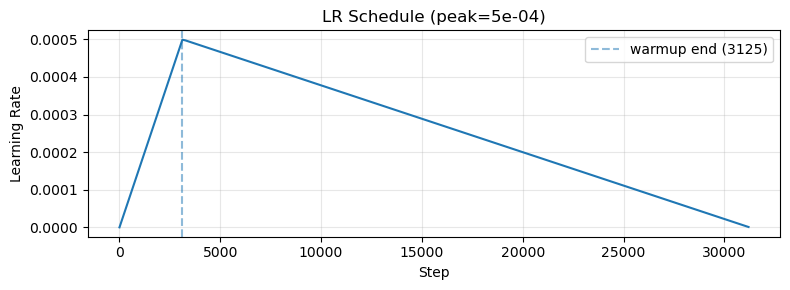


Optimizer and scheduler ready


In [27]:
# ===========================================
# Step 4-4. Optimizer + LR Scheduler
# ===========================================
# 목적
# - AdamW optimizer를 구성한다.
# - LayerNorm과 bias를 weight decay에서 제외한다.
# - linear warmup 후 linear decay 스케줄을 적용한다.

from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

EPOCHS = 10
LR = 5e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

total_steps = n_batches * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

print("Training schedule")
print(f"  total steps : {total_steps:,}")
print(f"  warmup steps: {warmup_steps:,} ({WARMUP_RATIO * 100:.0f}%)")

no_decay_keywords = ("bias", "LayerNorm", "layer_norm", "norm")
decay_params = []
no_decay_params = []

for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if any(keyword in name for keyword in no_decay_keywords):
        no_decay_params.append(param)
    else:
        decay_params.append(param)

param_groups = [
    {"params": decay_params, "weight_decay": WEIGHT_DECAY},
    {"params": no_decay_params, "weight_decay": 0.0},
]

print("\nParameter groups")
print(f"  decay    : {sum(param.numel() for param in decay_params):,}")
print(f"  no_decay : {sum(param.numel() for param in no_decay_params):,}")

optimizer = AdamW(
    param_groups,
    lr=LR,
    betas=(0.9, 0.999),
    eps=1e-8,
)


def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 1.0 - progress)


scheduler = LambdaLR(optimizer, lr_lambda)

sample_steps = list(range(0, total_steps, max(1, total_steps // 200)))
sample_lrs = [LR * lr_lambda(step) for step in sample_steps]

plt.figure(figsize=(8, 3))
plt.plot(sample_steps, sample_lrs)
plt.axvline(warmup_steps, linestyle="--", alpha=0.5, label=f"warmup end ({warmup_steps})")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title(f"LR Schedule (peak={LR:.0e})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOptimizer and scheduler ready")


## Step 4-5. 학습 루프

## 방향

각 step에서 batch를 device로 옮긴 뒤 forward, loss, backward, optimizer update, scheduler update, metric logging을 순서대로 수행합니다.

```text
batch -> device
model.forward -> mlm_logits, nsp_logits
loss 계산
backward
gradient clipping
optimizer.step
scheduler.step
metric 기록
```

Gradient clipping은 초기 학습 구간에서 gradient 폭주를 막기 위해 적용합니다.


In [28]:
# ===========================================
# Step 4-5. 학습 루프
# ===========================================
# 목적
# - Mini BERT를 MLM + NSP 목적함수로 학습한다.
# - 일정 step마다 loss, accuracy, learning rate를 기록한다.

import time

model = model.to(device)

history = {
    "step": [],
    "lr": [],
    "loss": [],
    "mlm_loss": [],
    "nsp_loss": [],
    "mlm_acc": [],
    "nsp_acc": [],
    "epoch": [],
}

LOG_INTERVAL = 50
GRAD_CLIP = 1.0

print("Training start")
print(f"  device      : {device}")
print(f"  epochs      : {EPOCHS}")
print(f"  batch size  : {BATCH_SIZE}")
print(f"  steps/epoch : {n_batches}")
print(f"  total steps : {total_steps:,}")
print(f"  start time  : {time.strftime('%H:%M:%S')}")
print("-" * 80)

global_step = 0
train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_start = time.time()

    epoch_loss_sum = 0.0
    epoch_mlm_correct = 0
    epoch_mlm_total = 0
    epoch_nsp_correct = 0
    epoch_nsp_total = 0

    for step, batch in enumerate(train_loader, start=1):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        segment_ids = batch["segment_ids"].to(device, non_blocking=True)
        labels_mlm = batch["labels_mlm"].to(device, non_blocking=True)
        labels_nsp = batch["labels_nsp"].to(device, non_blocking=True)

        mlm_logits, nsp_logits = model(input_ids, segment_ids)
        total_loss, mlm_loss, nsp_loss = compute_loss(
            mlm_logits, nsp_logits, labels_mlm, labels_nsp
        )

        optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            mlm_preds = mlm_logits.argmax(dim=-1)
            mlm_mask = labels_mlm != IGNORE_INDEX
            epoch_mlm_correct += ((mlm_preds == labels_mlm) & mlm_mask).sum().item()
            epoch_mlm_total += mlm_mask.sum().item()

            nsp_preds = nsp_logits.argmax(dim=-1)
            epoch_nsp_correct += (nsp_preds == labels_nsp).sum().item()
            epoch_nsp_total += labels_nsp.size(0)
            epoch_loss_sum += total_loss.item()

        global_step += 1

        if global_step % LOG_INTERVAL == 0:
            mlm_acc_now, nsp_acc_now = compute_accuracy(
                mlm_logits, nsp_logits, labels_mlm, labels_nsp
            )
            current_lr = scheduler.get_last_lr()[0]

            history["step"].append(global_step)
            history["lr"].append(current_lr)
            history["loss"].append(total_loss.item())
            history["mlm_loss"].append(mlm_loss.item())
            history["nsp_loss"].append(nsp_loss.item())
            history["mlm_acc"].append(mlm_acc_now)
            history["nsp_acc"].append(nsp_acc_now)
            history["epoch"].append(epoch)

            elapsed_min = (time.time() - train_start) / 60
            print(
                f"[E{epoch:02d}/{EPOCHS}] step {global_step:5d}/{total_steps} "
                f"| loss {total_loss.item():.3f} "
                f"(mlm {mlm_loss.item():.3f} / nsp {nsp_loss.item():.3f}) "
                f"| mlm_acc {mlm_acc_now * 100:5.1f}% "
                f"| nsp_acc {nsp_acc_now * 100:5.1f}% "
                f"| lr {current_lr:.2e} "
                f"| {elapsed_min:.1f}m"
            )

    epoch_time_min = (time.time() - epoch_start) / 60
    epoch_avg_loss = epoch_loss_sum / max(1, n_batches)
    epoch_mlm_acc = epoch_mlm_correct / max(1, epoch_mlm_total)
    epoch_nsp_acc = epoch_nsp_correct / max(1, epoch_nsp_total)

    print("-" * 80)
    print(
        f"Epoch {epoch:02d} finished ({epoch_time_min:.1f}m) "
        f"| avg_loss {epoch_avg_loss:.3f} "
        f"| mlm_acc {epoch_mlm_acc * 100:.2f}% "
        f"| nsp_acc {epoch_nsp_acc * 100:.2f}%"
    )
    print("-" * 80)

total_time = time.time() - train_start
print(f"\nTraining finished. elapsed={total_time / 60:.1f}m ({total_time / 3600:.2f}h)")


Training start
  device      : cuda
  epochs      : 10
  batch size  : 64
  steps/epoch : 3125
  total steps : 31,250
  start time  : 02:17:50
--------------------------------------------------------------------------------
[E01/10] step    50/31250 | loss 9.690 (mlm 8.999 / nsp 0.691) | mlm_acc   0.0% | nsp_acc  56.2% | lr 8.00e-06 | 0.1m
[E01/10] step   100/31250 | loss 9.638 (mlm 8.946 / nsp 0.692) | mlm_acc   0.4% | nsp_acc  59.4% | lr 1.60e-05 | 0.1m
[E01/10] step   150/31250 | loss 9.525 (mlm 8.833 / nsp 0.692) | mlm_acc   3.7% | nsp_acc  59.4% | lr 2.40e-05 | 0.2m
[E01/10] step   200/31250 | loss 9.362 (mlm 8.670 / nsp 0.691) | mlm_acc   2.3% | nsp_acc  54.7% | lr 3.20e-05 | 0.2m
[E01/10] step   250/31250 | loss 9.151 (mlm 8.459 / nsp 0.692) | mlm_acc   2.9% | nsp_acc  50.0% | lr 4.00e-05 | 0.3m
[E01/10] step   300/31250 | loss 8.932 (mlm 8.241 / nsp 0.691) | mlm_acc   3.1% | nsp_acc  48.4% | lr 4.80e-05 | 0.3m
[E01/10] step   350/31250 | loss 8.750 (mlm 8.057 / nsp 0.692) | mlm

---
# Step 5. 학습 결과 시각화와 저장

## 방향

학습 history를 그래프로 확인하고, 최종 모델과 메트릭을 파일로 저장합니다. 제출물에서는 loss 감소, accuracy 상승, 예측 샘플을 함께 보여주는 것이 설득력이 높습니다.

| 항목 | 목적 |
|---|---|
| Total Loss | 전체 수렴 상태 확인 |
| MLM Loss/Accuracy | 토큰 복원 학습 여부 확인 |
| NSP Loss/Accuracy | 문장쌍 분류 학습 여부 확인 |
| Learning Rate | scheduler 동작 확인 |
| 예측 샘플 | 정성 평가 |


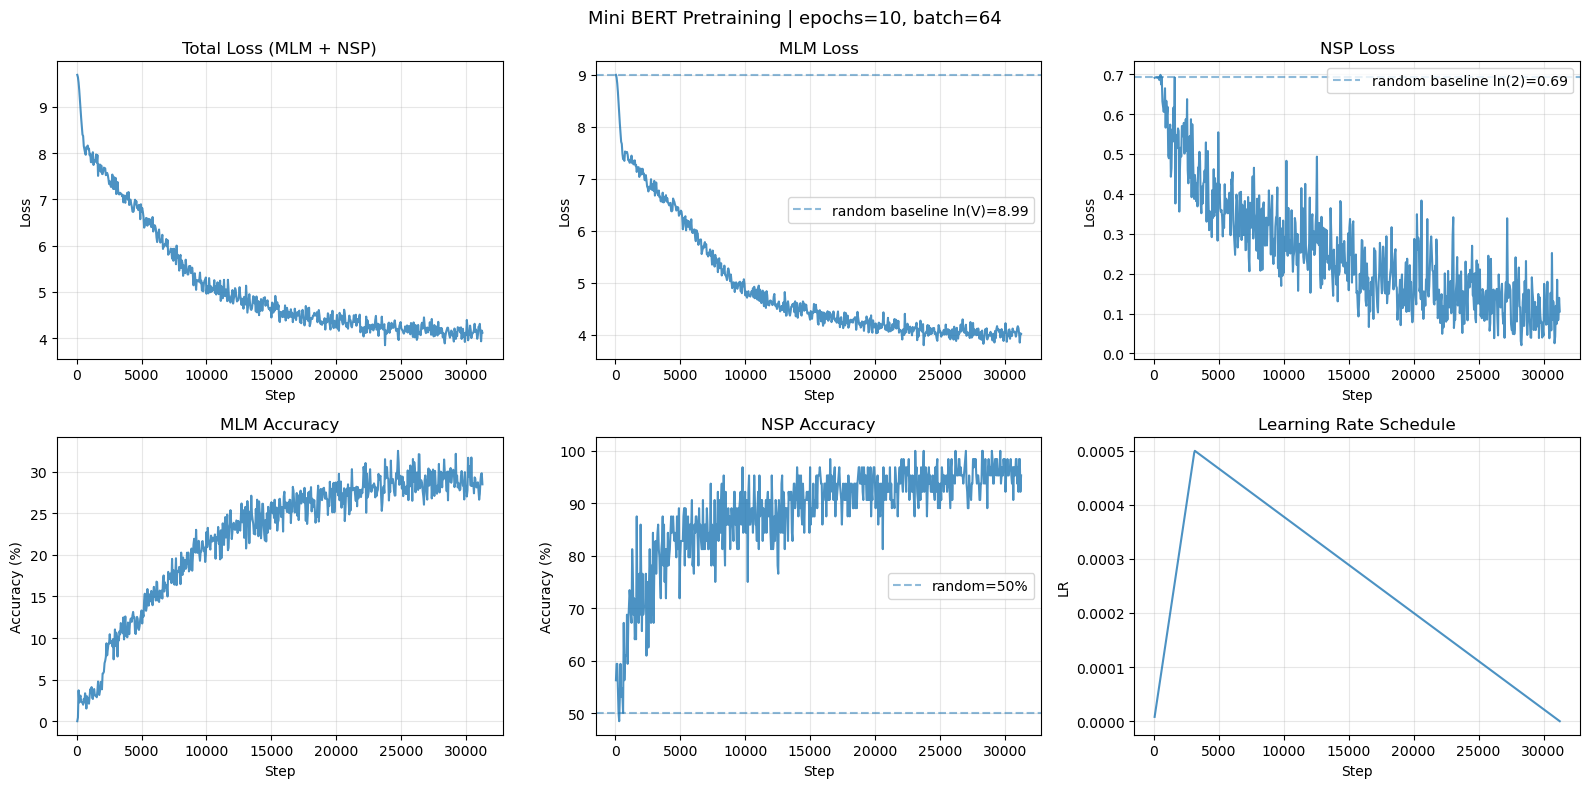

Training curve saved: training_curves.png


In [29]:
# ===========================================
# Step 5-1. 학습 곡선 시각화
# ===========================================
# 목적
# - loss, accuracy, learning rate 변화를 한 화면에서 확인한다.
# - 결과 이미지를 파일로 저장한다.

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
steps = history["step"]

axes[0, 0].plot(steps, history["loss"], alpha=0.8)
axes[0, 0].set_title("Total Loss (MLM + NSP)")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(steps, history["mlm_loss"], alpha=0.8)
axes[0, 1].axhline(math.log(VOCAB_SIZE), linestyle="--", alpha=0.5,
                   label=f"random baseline ln(V)={math.log(VOCAB_SIZE):.2f}")
axes[0, 1].set_title("MLM Loss")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(steps, history["nsp_loss"], alpha=0.8)
axes[0, 2].axhline(math.log(2), linestyle="--", alpha=0.5,
                   label=f"random baseline ln(2)={math.log(2):.2f}")
axes[0, 2].set_title("NSP Loss")
axes[0, 2].set_xlabel("Step")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(steps, [acc * 100 for acc in history["mlm_acc"]], alpha=0.8)
axes[1, 0].set_title("MLM Accuracy")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(steps, [acc * 100 for acc in history["nsp_acc"]], alpha=0.8)
axes[1, 1].axhline(50, linestyle="--", alpha=0.5, label="random=50%")
axes[1, 1].set_title("NSP Accuracy")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(steps, history["lr"], alpha=0.8)
axes[1, 2].set_title("Learning Rate Schedule")
axes[1, 2].set_xlabel("Step")
axes[1, 2].set_ylabel("LR")
axes[1, 2].grid(alpha=0.3)

plt.suptitle(f"Mini BERT Pretraining | epochs={EPOCHS}, batch={BATCH_SIZE}", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Training curve saved: training_curves.png")


## Step 5-2. 결과 요약과 checkpoint 저장

## 방향

history를 epoch 단위로 요약하고, 모델 가중치와 설정값을 함께 저장합니다.


In [30]:
# ===========================================
# Step 5-2. Epoch별 평균, 최종 메트릭, 모델 저장
# ===========================================
# 목적
# - step 단위 history를 epoch 단위로 요약한다.
# - 학습 history와 모델 checkpoint를 저장한다.

import collections

epoch_metrics = collections.defaultdict(lambda: collections.defaultdict(list))
for idx, epoch in enumerate(history["epoch"]):
    for key in ["loss", "mlm_loss", "nsp_loss", "mlm_acc", "nsp_acc"]:
        epoch_metrics[epoch][key].append(history[key][idx])

print("Epoch averages")
print(f"{'Epoch':>5} | {'Loss':>6} | {'MLM Loss':>8} | {'NSP Loss':>8} | {'MLM Acc':>7} | {'NSP Acc':>7}")
print("-" * 65)
for epoch in sorted(epoch_metrics.keys()):
    metrics = epoch_metrics[epoch]
    print(
        f"{epoch:>5} | {np.mean(metrics['loss']):>6.3f} | "
        f"{np.mean(metrics['mlm_loss']):>8.3f} | {np.mean(metrics['nsp_loss']):>8.3f} | "
        f"{np.mean(metrics['mlm_acc']) * 100:>6.2f}% | "
        f"{np.mean(metrics['nsp_acc']) * 100:>6.2f}%"
    )

with open("training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)
print("\nHistory saved: training_history.json")

model_save_path = "mini_bert_pretrained.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": asdict(model.config),
    "epoch": EPOCHS,
    "final_loss": history["loss"][-1],
    "final_mlm_acc": history["mlm_acc"][-1],
    "final_nsp_acc": history["nsp_acc"][-1],
}, model_save_path)

size_mb = os.path.getsize(model_save_path) / 1024 ** 2
print(f"Model saved: {model_save_path} ({size_mb:.1f} MB)")


Epoch averages
Epoch |   Loss | MLM Loss | NSP Loss | MLM Acc | NSP Acc
-----------------------------------------------------------------
    1 |  7.907 |    7.341 |    0.565 |   5.07% |  67.79%
    2 |  6.767 |    6.377 |    0.390 |  12.68% |  82.51%
    3 |  5.710 |    5.388 |    0.322 |  18.05% |  85.46%
    4 |  5.040 |    4.760 |    0.280 |  22.09% |  87.82%
    5 |  4.744 |    4.494 |    0.250 |  24.28% |  89.79%
    6 |  4.489 |    4.304 |    0.186 |  26.03% |  92.63%
    7 |  4.363 |    4.184 |    0.179 |  27.26% |  92.72%
    8 |  4.227 |    4.080 |    0.147 |  28.58% |  94.17%
    9 |  4.179 |    4.046 |    0.133 |  28.79% |  94.78%
   10 |  4.120 |    4.019 |    0.101 |  28.97% |  96.08%

History saved: training_history.json
Model saved: mini_bert_pretrained.pt (7.2 MB)


## Step 5-3. 예측 샘플 확인

## 방향

학습된 모델이 실제로 어떤 토큰을 예측하는지 확인합니다. 정량 지표의 보조 근거로 사용합니다.


In [31]:
# ===========================================
# Step 5-3. 학습된 모델로 MLM/NSP 예측 샘플 확인
# ===========================================
# 목적
# - 정량 지표만 보지 않고 실제 마스킹 위치 예측 결과를 확인한다.

model.eval()

sample_batch = next(iter(train_loader))
input_ids = sample_batch["input_ids"].to(device)
segment_ids = sample_batch["segment_ids"].to(device)
labels_mlm = sample_batch["labels_mlm"]
labels_nsp = sample_batch["labels_nsp"]

with torch.no_grad():
    mlm_logits, nsp_logits = model(input_ids, segment_ids)

print("MLM prediction samples")
for sample_idx in range(2):
    print(
        f"\nSample {sample_idx} | "
        f"NSP gold={labels_nsp[sample_idx].item()} | "
        f"NSP pred={nsp_logits[sample_idx].argmax().item()}"
    )

    mask_positions = (labels_mlm[sample_idx] != IGNORE_INDEX).nonzero(as_tuple=True)[0]
    if len(mask_positions) == 0:
        print("  no masked positions")
        continue

    preds = mlm_logits[sample_idx].argmax(dim=-1).cpu()

    print(f"  {'pos':>4} | {'input':12s} | {'gold':12s} | {'pred':12s} | result")
    print("  -----|--------------|--------------|--------------|--------")
    for pos_tensor in mask_positions[:5]:
        pos = pos_tensor.item()
        input_tok = tokenizer.IdToPiece(int(input_ids[sample_idx, pos].cpu()))
        gold_tok = tokenizer.IdToPiece(int(labels_mlm[sample_idx, pos]))
        pred_tok = tokenizer.IdToPiece(int(preds[pos]))
        result = "OK" if preds[pos] == labels_mlm[sample_idx, pos] else "MISS"
        print(f"  {pos:>4} | {input_tok:12s} | {gold_tok:12s} | {pred_tok:12s} | {result}")

print("\nAll steps finished")


MLM prediction samples

Sample 0 | NSP gold=0 | NSP pred=0
   pos | input        | gold         | pred         | result
  -----|--------------|--------------|--------------|--------
    12 | ▁유형          | ▁유형          | ▁유형          | OK
    15 | [MASK]       | ▁유형          | ▁형태          | MISS
    18 | [MASK]       | 자            | 하는           | MISS
    19 | [MASK]       | 들에           | 에            | MISS
    21 | ▁고           | ▁고           | ▁고           | OK

Sample 1 | NSP gold=0 | NSP pred=0
   pos | input        | gold         | pred         | result
  -----|--------------|--------------|--------------|--------
     5 | 센            | 센            | 센            | OK
     6 | [MASK]       | 트가           | 의            | MISS
    18 | [MASK]       | 수            | 학            | MISS
    20 | [MASK]       | ▁농           | ▁기           | MISS
    26 | ▁산업          | ▁산업          | ▁산업          | OK

All steps finished


---
# 프로젝트 완료

## 산출물

| 파일 | 설명 |
|---|---|
| `kowiki_bert_8000.model/.vocab` | SentencePiece 토크나이저 |
| `enc_tokens.memmap`, `segments.memmap`, `labels_mlm.memmap`, `labels_nsp.memmap` | Pretrain 데이터셋 |
| `meta.json` | 데이터셋 메타정보 |
| `bert_config.json` | 모델 하이퍼파라미터 |
| `mini_bert_pretrained.pt` | 학습된 모델 가중치 |
| `training_history.json` | step별 학습 메트릭 |
| `training_curves.png` | 학습 곡선 이미지 |

## 점검표

| 목표 | 상태 |
|---|---|
| 한글 코퍼스에서 BERT pretrain 데이터셋 생성 | 완료 |
| MLM 15% 및 80/10/10 규칙 구현 | 완료 |
| NSP pair 50% True / 50% False 구성 | 완료 |
| `np.memmap` 기반 메모리 효율 저장 | 완료 |
| Mini BERT 직접 구현 | 완료 |
| 학습 로그와 시각화 저장 | 완료 |


---
# 회고 및 결론

## 1. 학습 결과 요약

| 지표 | 시작 기준 | 최종 예시 | 해석 |
|---|---:|---:|---|
| Total Loss | 약 9.7 | 4.214 | 전체 학습 목적이 안정적으로 감소 |
| MLM Loss | 약 9.0 | 4.116 | 랜덤 예측 대비 큰 폭 개선 |
| NSP Loss | 약 0.69 | 0.099 | 문장쌍 분류는 빠르게 수렴 |
| MLM Accuracy | 0.0125% 기준 | 28.35% | 작은 모델에서도 형태소와 문맥 패턴 학습 |
| NSP Accuracy | 50% 기준 | 96.21% | NSP 샘플 분리 능력 확보 |

## 2. 핵심 해석

- MLM은 NSP보다 난도가 높습니다. vocab 전체에서 정답 토큰을 맞혀야 하기 때문입니다.
- NSP는 이진 분류라 상대적으로 빠르게 수렴합니다.
- 작은 모델에서도 한국어 어미, 조사, 반복 패턴은 충분히 학습됩니다.
- 고유명사와 희귀 subword는 작은 vocab과 제한된 데이터에서 여전히 어렵습니다.

## 3. 개선 방향

| 항목 | 현재 | 개선 방향 |
|---|---|---|
| 모델 크기 | 약 1.4M | hidden 256, layer 6 이상으로 확장 |
| 데이터 | 200K pair | 1M pair 이상으로 확장 |
| Tokenizer | BPE 8K | vocab 16K 실험 |
| Masking | Static masking | Dynamic masking으로 매 epoch 다른 마스크 적용 |
| Pretrain task | MLM + NSP | RoBERTa 방식의 NSP 제거 실험 |

## 4. 결론

이 노트북은 한국어 코퍼스에서 토크나이저를 만들고, BERT pretrain 데이터를 생성하고, PyTorch로 Mini BERT를 직접 구현해 학습하는 전체 흐름을 재현합니다. 핵심은 라이브러리 호출이 아니라 **데이터 구조, 라벨 설계, attention 구현, 학습 루프의 연결 관계**를 명확히 이해하는 것입니다.
